# Network 2 variable discovery: first three stations

This is **mapping stage 1**, not the final QC run. It profiles the three smallest station IDs in network 2 and evaluates candidate source names for six canonical daily variables: `air_temperature`, `daily_min_temperature`, `daily_max_temperature`, `precipitation_amount`, `snowfall_amount`, and `snow_depth`.

A name match remains a candidate until its metadata, coverage, cadence, physical range, temporal meaning, and agreement with overlapping sources have been reviewed. Tables and figures are saved under `outputs/mapping_stage_1/`.

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Setup

In [2]:
from variable_mapping import (
    CANONICAL_VARIABLES, CANDIDATE_MAPPINGS,
    add_observation_diagnostics, fetch_available_variables,
    fetch_candidate_observations, fetch_network_catalog, mapping_matrix,
    overlap_comparison, profile_candidates, select_smallest_stations,
)
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlalchemy as sa
from IPython.display import display

HERE = Path.cwd()
if not (HERE / 'variable_mapping.py').exists():
    HERE = Path('/workspaces/crmprtd/Quanlity_Control/pipeline/v2_July')
sys.path.insert(0, str(HERE))

OUTPUT_DIR = HERE / 'outputs' / 'mapping_stage_1'
FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DB_URL = os.getenv(
    'CRMP_DB_URL',
    'postgresql://tongli1997@proddb01.pcic.uvic.ca,proddb02.pcic.uvic.ca/crmp'
    '?keepalives=1&keepalives_idle=300&keepalives_interval=300'
    '&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass',
)
engine = sa.create_engine(DB_URL, pool_pre_ping=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## 2. Select stations and inspect metadata

Selection uses `meta_station.station_id`; every matching history is retained because mappings may change across history periods.

In [3]:
stations = select_smallest_stations(engine, network_id=2, limit=3)
stations.to_csv(OUTPUT_DIR / 'selected_station_histories.csv', index=False)
display(stations)

,station_id,native_id,min_obs_time,max_obs_time,history_id,station_name,lon,lat,elev,sdate,edate,tz_offset,freq
0,2654,11091,2001-01-22 13:00:00,2011-04-06 11:00:00,3397,Brandywine,-123.11806,50.05417,496.0,None,None,None,1-hourly
1,2655,11092,2009-06-25 16:00:00,2011-04-06 11:00:00,3398,Tantalus,-123.14339,49.84347,320.0,None,None,None,1-hourly
2,2657,11121,1993-12-22 16:00:00,2011-04-05 15:00:00,3400,Mt. Strachan Precip,-123.19144,49.40431,1220.0,None,None,None,1-hourly


The initial database review identifies station 2654 (Brandywine), 2655 (Tantalus), and 2657 (Mt. Strachan Precip). History frequency is hourly, but timezone offsets are empty. A local observation-day rule therefore cannot yet be approved.

## 3. Network catalog and actual station availability

The catalog describes every registered network-2 variable. Availability is checked separately because a catalog entry does not guarantee observations at a station.

In [4]:
catalog = fetch_network_catalog(engine, network_id=2)
available = fetch_available_variables(engine, stations)
catalog.to_csv(OUTPUT_DIR / 'network_2_variable_catalog.csv', index=False)
available.to_csv(
    OUTPUT_DIR / 'selected_station_available_variables.csv', index=False)
print(f'Network catalog: {len(catalog):,} variables')
print(f'Station/history/variable combinations: {len(available):,}')
display(catalog[['vars_id', 'net_var_name',
        'unit', 'standard_name', 'cell_method']])

Network catalog: 37 variables
Station/history/variable combinations: 98


,vars_id,net_var_name,unit,standard_name,cell_method
0,445,ACTUAL_WIND_DIRECTION,degrees,wind_from_direction,time: point
1,444,ACTUAL_WIND_SPEED,NaN,wind_speed,time: point
2,721,air_temp,celsius,air_temperature,time: point
3,439,ATMOSPHERIC_PRESSURE,millibar,air_pressure,time: point
4,731,avg_wnd_dir_10m_pst10mts,degrees,wind_from_direction,time: mean
5,729,avg_wnd_spd_10m_pst10mts,km/h,wind_speed,time: mean
6,434,CURRENT_AIR_TEMPERATURE1,celsius,air_temperature,time: point
7,436,CURRENT_AIR_TEMPERATURE2,celsius,air_temperature,time: point
8,438,DEW_POINT,celsius,dew_point_temperature,time: mean
9,724,dwpt_temp,celsius,dew_point_temperature,time: point


In [5]:
available

,station_id,history_id,station_name,vars_id,net_var_name,unit,standard_name,cell_method,display_name,short_name,long_description
0,2654,3397,Brandywine,445,ACTUAL_WIND_DIRECTION,degrees,wind_from_direction,time: point,Wind Direction (Point),wind_from_direction_point,NaN
1,2654,3397,Brandywine,444,ACTUAL_WIND_SPEED,NaN,wind_speed,time: point,Wind Speed (Point),wind_speed_point,NaN
2,2654,3397,Brandywine,721,air_temp,celsius,air_temperature,time: point,Temperature (Mean),T,NaN
3,2654,3397,Brandywine,439,ATMOSPHERIC_PRESSURE,millibar,air_pressure,time: point,Air Pressure (Point),air_pressure_point,NaN
4,2654,3397,Brandywine,731,avg_wnd_dir_10m_pst10mts,degrees,wind_from_direction,time: mean,Wind Direction,wdir,NaN
...,...,...,...,...,...,...,...,...,...,...,...
93,2657,3400,Mt. Strachan Precip,725,stn_pres,hPa,air_pressure,time: point,Air Pressure,Air Pressure,NaN
94,2657,3400,Mt. Strachan Precip,563,T_mean_Climatology,celsius,air_temperature,t: mean within days t: mean within months t: m...,Temperature Climatology (Mean),air_temperaturet: mean within days t: mean wit...,Climatological mean of monthly mean of mean da...
95,2657,3400,Mt. Strachan Precip,562,Tn_Climatology,celsius,air_temperature,t: minimum within days t: mean within months t...,Temperature Climatology (Min.),air_temperaturet: minimum within days t: mean ...,Climatological mean of monthly mean minimum da...
96,2657,3400,Mt. Strachan Precip,561,Tx_Climatology,celsius,air_temperature,t: maximum within days t: mean within months t...,Temperature Climatology (Max.),air_temperaturet: maximum within days t: mean ...,Climatological mean of monthly mean maximum da...


In [6]:
CANDIDATE_MAPPINGS

,vars_id,net_var_name,canonical_variable,source_type,daily_aggregation,priority,source_family,mapping_status
0,721,air_temp,air_temperature,point,mean,1,modern,candidate
1,434,CURRENT_AIR_TEMPERATURE1,air_temperature,point,mean,2,legacy,candidate
2,436,CURRENT_AIR_TEMPERATURE2,air_temperature,point,mean,3,legacy_fallback,candidate
3,722,min_air_temp_snc_last_reset,daily_min_temperature,running_minimum,last,1,modern,candidate
4,435,MINIMUM_AIR_TEMPERATURE,daily_min_temperature,interval_minimum,min,2,legacy,candidate
5,720,max_air_temp_snc_last_reset,daily_max_temperature,running_maximum,last,1,modern,candidate
6,433,MAXIMUM_AIR_TEMPERATURE,daily_max_temperature,interval_maximum,max,2,legacy,candidate
7,726,pcpn_amt_pst1hr,precipitation_amount,one_hour_amount,sum,1,modern,candidate
8,442,HOURLY_PRECIPITATION,precipitation_amount,hourly_or_daily_amount,review,2,legacy,candidate
9,728,snwfl_amt_pst1hr,snowfall_amount,one_hour_amount,sum,1,modern,candidate


In [7]:
candidate_availability = available.merge(
    CANDIDATE_MAPPINGS, on=['vars_id', 'net_var_name'], how='inner'
)
display(candidate_availability[[
    'station_id', 'station_name', 'vars_id', 'net_var_name', 'unit', 'standard_name',
    'cell_method', 'canonical_variable', 'source_type', 'source_family',
    'priority', 'mapping_status'
]].sort_values(['station_id', 'canonical_variable', 'priority']))

,station_id,station_name,vars_id,net_var_name,unit,standard_name,cell_method,canonical_variable,source_type,source_family,priority,mapping_status
0,2654,Brandywine,721,air_temp,celsius,air_temperature,time: point,air_temperature,point,modern,1,candidate
1,2654,Brandywine,434,CURRENT_AIR_TEMPERATURE1,celsius,air_temperature,time: point,air_temperature,point,legacy,2,candidate
2,2654,Brandywine,436,CURRENT_AIR_TEMPERATURE2,celsius,air_temperature,time: point,air_temperature,point,legacy_fallback,3,candidate
5,2654,Brandywine,720,max_air_temp_snc_last_reset,celsius,air_temperature,time: maximum,daily_max_temperature,running_maximum,modern,1,candidate
6,2654,Brandywine,433,MAXIMUM_AIR_TEMPERATURE,celsius,air_temperature,time: maximum,daily_max_temperature,interval_maximum,legacy,2,candidate
7,2654,Brandywine,722,min_air_temp_snc_last_reset,celsius,air_temperature,time: minimum,daily_min_temperature,running_minimum,modern,1,candidate
8,2654,Brandywine,435,MINIMUM_AIR_TEMPERATURE,celsius,air_temperature,time: minimum,daily_min_temperature,interval_minimum,legacy,2,candidate
9,2654,Brandywine,726,pcpn_amt_pst1hr,mm,lwe_thickness_of_precipitation_amount,time: sum (interval: 1 hour),precipitation_amount,one_hour_amount,modern,1,candidate
4,2654,Brandywine,442,HOURLY_PRECIPITATION,mm,lwe_thickness_of_precipitation_amount,t: sum within days interval: daily,precipitation_amount,hourly_or_daily_amount,legacy,2,candidate
10,2654,Brandywine,727,snw_dpth,cm,surface_snow_thickness,time: point,snow_depth,point,modern,1,candidate


## 4. Coverage and raw-range profile

Raw minima and maxima intentionally retain sentinels and instrument failures. They show which cleaning is required before daily aggregation; they do not automatically disqualify a semantically correct mapping.

In [8]:
candidate_profile = profile_candidates(engine, stations)
candidate_profile.to_csv(
    OUTPUT_DIR / 'candidate_coverage_profile.csv', index=False)
display(candidate_profile[[
    'station_id', 'station_name', 'canonical_variable', 'vars_id', 'net_var_name',
    'source_family', 'source_type', 'daily_aggregation', 'priority', 'row_count',
    'first_observation', 'last_observation', 'rows_per_coverage_day',
    'observed_min', 'observed_max'
]].sort_values(['station_id', 'canonical_variable', 'priority']))
matrix = mapping_matrix(candidate_profile)
matrix.to_csv(OUTPUT_DIR / 'candidate_mapping_matrix.csv')
display(matrix)

,station_id,station_name,canonical_variable,vars_id,net_var_name,source_family,source_type,daily_aggregation,priority,row_count,first_observation,last_observation,rows_per_coverage_day,observed_min,observed_max
8,2654,Brandywine,air_temperature,721,air_temp,modern,point,mean,1,45044,2020-01-08 11:00:00,2026-07-17 10:00:00,18.902555,-113.000,42.10
1,2654,Brandywine,air_temperature,434,CURRENT_AIR_TEMPERATURE1,legacy,point,mean,2,187675,2001-01-22 13:00:00,2023-03-18 09:00:00,23.196004,-73.320,42.06
3,2654,Brandywine,air_temperature,436,CURRENT_AIR_TEMPERATURE2,legacy_fallback,point,mean,3,85548,2001-01-22 13:00:00,2011-04-06 11:00:00,22.954095,-127.500,40.20
7,2654,Brandywine,daily_max_temperature,720,max_air_temp_snc_last_reset,modern,running_maximum,last,1,45044,2020-01-08 11:00:00,2026-07-17 10:00:00,18.902555,-20.800,42.80
0,2654,Brandywine,daily_max_temperature,433,MAXIMUM_AIR_TEMPERATURE,legacy,interval_maximum,max,2,88246,2001-01-22 13:00:00,2011-04-06 11:00:00,23.678018,-17.390,40.46
9,2654,Brandywine,daily_min_temperature,722,min_air_temp_snc_last_reset,modern,running_minimum,last,1,45044,2020-01-08 11:00:00,2026-07-17 10:00:00,18.902555,-3497.000,36.30
2,2654,Brandywine,daily_min_temperature,435,MINIMUM_AIR_TEMPERATURE,legacy,interval_minimum,min,2,88225,2001-01-22 13:00:00,2011-04-06 11:00:00,23.672383,-117.200,33.94
10,2654,Brandywine,precipitation_amount,726,pcpn_amt_pst1hr,modern,one_hour_amount,sum,1,45034,2020-01-08 11:00:00,2026-07-17 10:00:00,18.898358,-2.000,13.10
4,2654,Brandywine,precipitation_amount,442,HOURLY_PRECIPITATION,legacy,hourly_or_daily_amount,review,2,165372,2001-01-22 13:00:00,2023-03-18 09:00:00,20.439427,-784.000,6999.00
11,2654,Brandywine,snow_depth,727,snw_dpth,modern,point,fixed_hour,1,26366,2020-01-08 11:00:00,2026-04-22 02:00:00,11.480324,-7999.000,119.00


canonical_variable,air_temperature,daily_min_temperature,daily_max_temperature,precipitation_amount,snowfall_amount,snow_depth
station_id,,,,,,
2654,"CURRENT_AIR_TEMPERATURE1 [legacy, p2]; CURRENT...","MINIMUM_AIR_TEMPERATURE [legacy, p2]; min_air_...","MAXIMUM_AIR_TEMPERATURE [legacy, p2]; max_air_...","HOURLY_PRECIPITATION [legacy, p2]; pcpn_amt_ps...","STANDARD_SNOW [legacy, p2]; snwfl_amt_pst1hr [...","HEIGHT_OF_SNOW [legacy, p2]; snw_dpth [modern,..."
2655,"CURRENT_AIR_TEMPERATURE1 [legacy, p2]; CURRENT...","MINIMUM_AIR_TEMPERATURE [legacy, p2]; min_air_...","MAXIMUM_AIR_TEMPERATURE [legacy, p2]; max_air_...","HOURLY_PRECIPITATION [legacy, p2]; pcpn_amt_ps...","STANDARD_SNOW [legacy, p2]; snwfl_amt_pst1hr [...","HEIGHT_OF_SNOW [legacy, p2]; snw_dpth [modern,..."
2657,"CURRENT_AIR_TEMPERATURE1 [legacy, p2]; air_tem...","MINIMUM_AIR_TEMPERATURE [legacy, p2]; min_air_...","MAXIMUM_AIR_TEMPERATURE [legacy, p2]; max_air_...","HOURLY_PRECIPITATION [legacy, p2]; pcpn_amt_ps...","STANDARD_SNOW [legacy, p2]; snwfl_amt_pst1hr [...","snw_dpth [modern, p1]"


### Coverage visualization

Overlapping source periods provide validation opportunities, but overlapping values must never be concatenated or averaged silently.

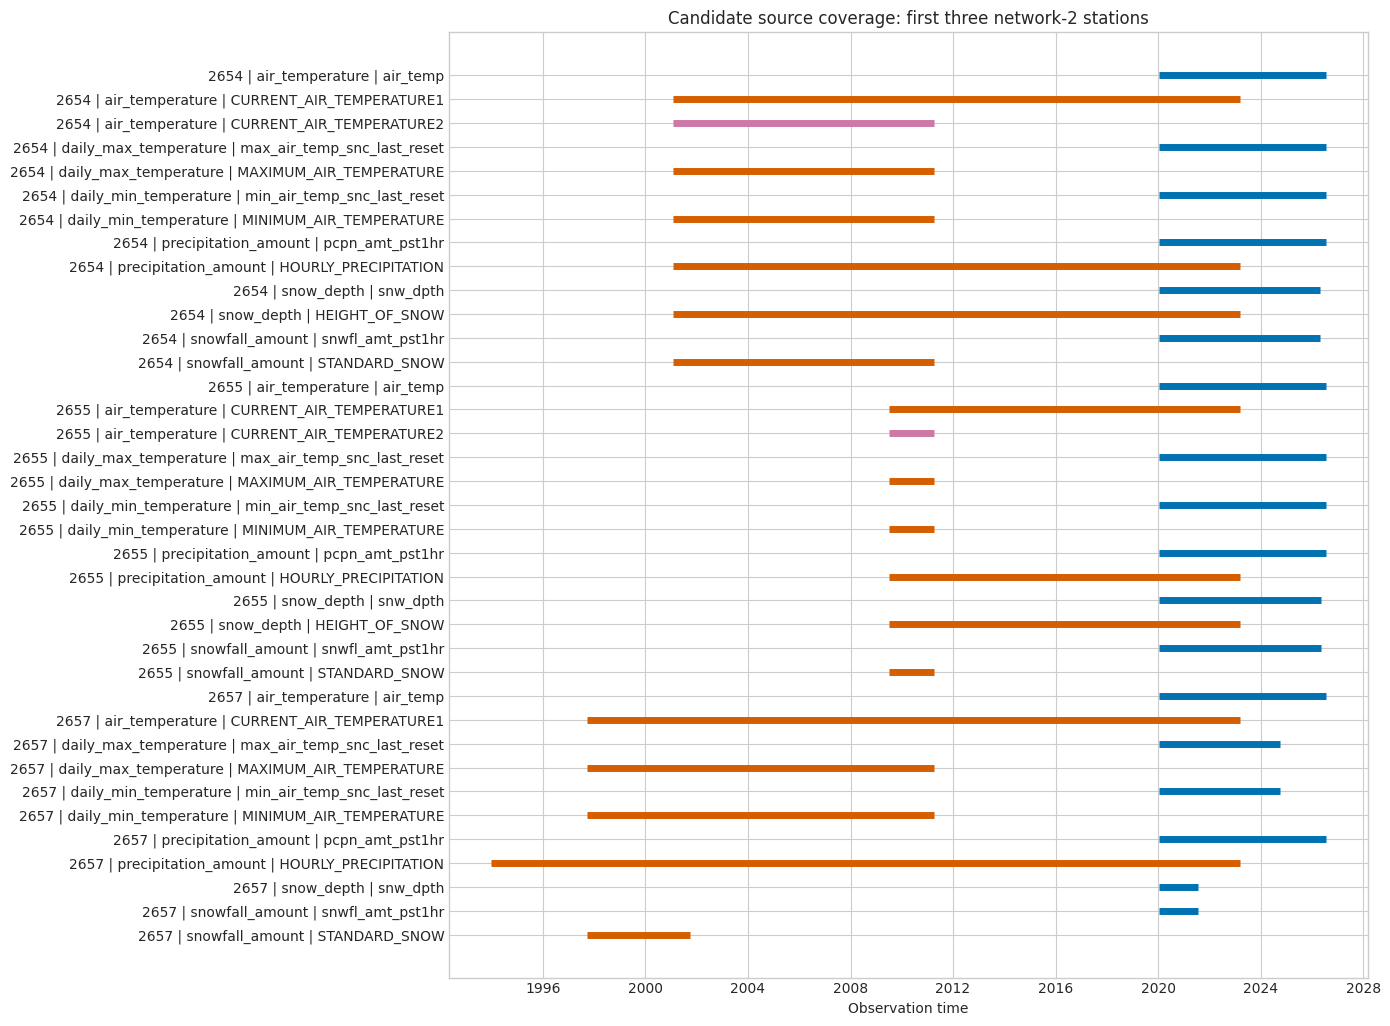

In [9]:
plot_data = candidate_profile.sort_values(
    ['station_id', 'canonical_variable', 'priority', 'vars_id']
).reset_index(drop=True)
labels = (plot_data['station_id'].astype(str) + ' | ' +
          plot_data['canonical_variable'] + ' | ' + plot_data['net_var_name'])
colors = {'modern': '#0072B2', 'legacy': '#D55E00',
          'legacy_fallback': '#CC79A7', 'derived_fallback': '#009E73'}
fig, ax = plt.subplots(figsize=(14, max(8, .28*len(plot_data))))
for y, row in plot_data.iterrows():
    ax.plot([row.first_observation, row.last_observation], [y, y], linewidth=5,
            solid_capstyle='butt', color=colors.get(row.source_family, '#666'))
ax.set_yticks(range(len(plot_data)), labels=labels)
ax.invert_yaxis()
ax.set_title('Candidate source coverage: first three network-2 stations')
ax.set_xlabel('Observation time')
fig.tight_layout()
fig.savefig(FIGURE_DIR/'candidate_coverage.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Detailed cadence and physical-range diagnostics

Only registered candidate sources are loaded. Physical limits are broad screening limits. Flagged values remain visible here; the future QC pipeline will preserve the raw value and set confirmed invalid working values to `NaN` before aggregation.

In [10]:
observations = fetch_candidate_observations(
    engine, stations.history_id.dropna().astype(int).unique().tolist(),
    CANDIDATE_MAPPINGS.vars_id.unique().tolist(),
)
diagnostic_data, diagnostic_summary = add_observation_diagnostics(observations)
diagnostic_summary.to_csv(
    OUTPUT_DIR/'candidate_diagnostic_summary.csv', index=False)
display(diagnostic_summary.sort_values(
    ['station_id', 'canonical_variable', 'vars_id']
))

,station_id,station_name,vars_id,net_var_name,canonical_variable,row_count,valid_numeric_count,implausible_count,raw_min,raw_median,raw_max,first_observation,last_observation,implausible_pct,median_interval_hours
1,2654,Brandywine,434,CURRENT_AIR_TEMPERATURE1,air_temperature,187675,187675,0,-73.320,6.198,42.06,2001-01-22 13:00:00,2023-03-18 09:00:00,0.000000,1.0
3,2654,Brandywine,436,CURRENT_AIR_TEMPERATURE2,air_temperature,85548,85548,1,-127.500,4.939,40.20,2001-01-22 13:00:00,2011-04-06 11:00:00,0.001169,1.0
8,2654,Brandywine,721,air_temp,air_temperature,45044,45044,1,-113.000,6.000,42.10,2020-01-08 11:00:00,2026-07-17 10:00:00,0.002220,1.0
0,2654,Brandywine,433,MAXIMUM_AIR_TEMPERATURE,daily_max_temperature,88246,88246,0,-17.390,7.980,40.46,2001-01-22 13:00:00,2011-04-06 11:00:00,0.000000,1.0
7,2654,Brandywine,720,max_air_temp_snc_last_reset,daily_max_temperature,45044,45044,0,-20.800,8.300,42.80,2020-01-08 11:00:00,2026-07-17 10:00:00,0.000000,1.0
2,2654,Brandywine,435,MINIMUM_AIR_TEMPERATURE,daily_min_temperature,88225,88225,5,-117.200,2.985,33.94,2001-01-22 13:00:00,2011-04-06 11:00:00,0.005667,1.0
9,2654,Brandywine,722,min_air_temp_snc_last_reset,daily_min_temperature,45044,45044,8,-3497.000,3.500,36.30,2020-01-08 11:00:00,2026-07-17 10:00:00,0.017760,1.0
4,2654,Brandywine,442,HOURLY_PRECIPITATION,precipitation_amount,165372,165372,44013,-784.000,0.000,6999.00,2001-01-22 13:00:00,2023-03-18 09:00:00,26.614542,1.0
10,2654,Brandywine,726,pcpn_amt_pst1hr,precipitation_amount,45034,45034,11117,-2.000,0.000,13.10,2020-01-08 11:00:00,2026-07-17 10:00:00,24.685793,1.0
5,2654,Brandywine,450,HEIGHT_OF_SNOW,snow_depth,133853,133853,50653,-4.482,0.835,218.60,2001-01-22 13:00:00,2023-03-18 09:00:00,37.842260,1.0


In [11]:
invalid_summary = diagnostic_summary.loc[
    diagnostic_summary.implausible_count > 0,
    ['station_id', 'canonical_variable', 'vars_id', 'net_var_name', 'row_count',
     'implausible_count', 'implausible_pct', 'raw_min', 'raw_median', 'raw_max',
     'median_interval_hours']
].sort_values(['station_id', 'canonical_variable', 'implausible_pct'],
              ascending=[True, True, False])
invalid_summary.to_csv(
    OUTPUT_DIR/'candidate_invalid_value_summary.csv', index=False)
display(invalid_summary)

,station_id,canonical_variable,vars_id,net_var_name,row_count,implausible_count,implausible_pct,raw_min,raw_median,raw_max,median_interval_hours
8,2654,air_temperature,721,air_temp,45044,1,0.002220,-113.000,6.000,42.10,1.0
3,2654,air_temperature,436,CURRENT_AIR_TEMPERATURE2,85548,1,0.001169,-127.500,4.939,40.20,1.0
9,2654,daily_min_temperature,722,min_air_temp_snc_last_reset,45044,8,0.017760,-3497.000,3.500,36.30,1.0
2,2654,daily_min_temperature,435,MINIMUM_AIR_TEMPERATURE,88225,5,0.005667,-117.200,2.985,33.94,1.0
4,2654,precipitation_amount,442,HOURLY_PRECIPITATION,165372,44013,26.614542,-784.000,0.000,6999.00,1.0
10,2654,precipitation_amount,726,pcpn_amt_pst1hr,45034,11117,24.685793,-2.000,0.000,13.10,1.0
5,2654,snow_depth,450,HEIGHT_OF_SNOW,133853,50653,37.842260,-4.482,0.835,218.60,1.0
11,2654,snow_depth,727,snw_dpth,26366,1018,3.861033,-7999.000,9.000,119.00,1.0
12,2654,snowfall_amount,728,snwfl_amt_pst1hr,26364,1645,6.239569,-8.000,0.000,10.00,1.0
16,2655,air_temperature,436,CURRENT_AIR_TEMPERATURE2,15548,1,0.006432,-348.800,6.350,34.60,1.0


### Candidate distributions

Implausible values are excluded so sentinels do not flatten the plot. Plot samples are limited to 30,000 per source; summary statistics use every loaded record.

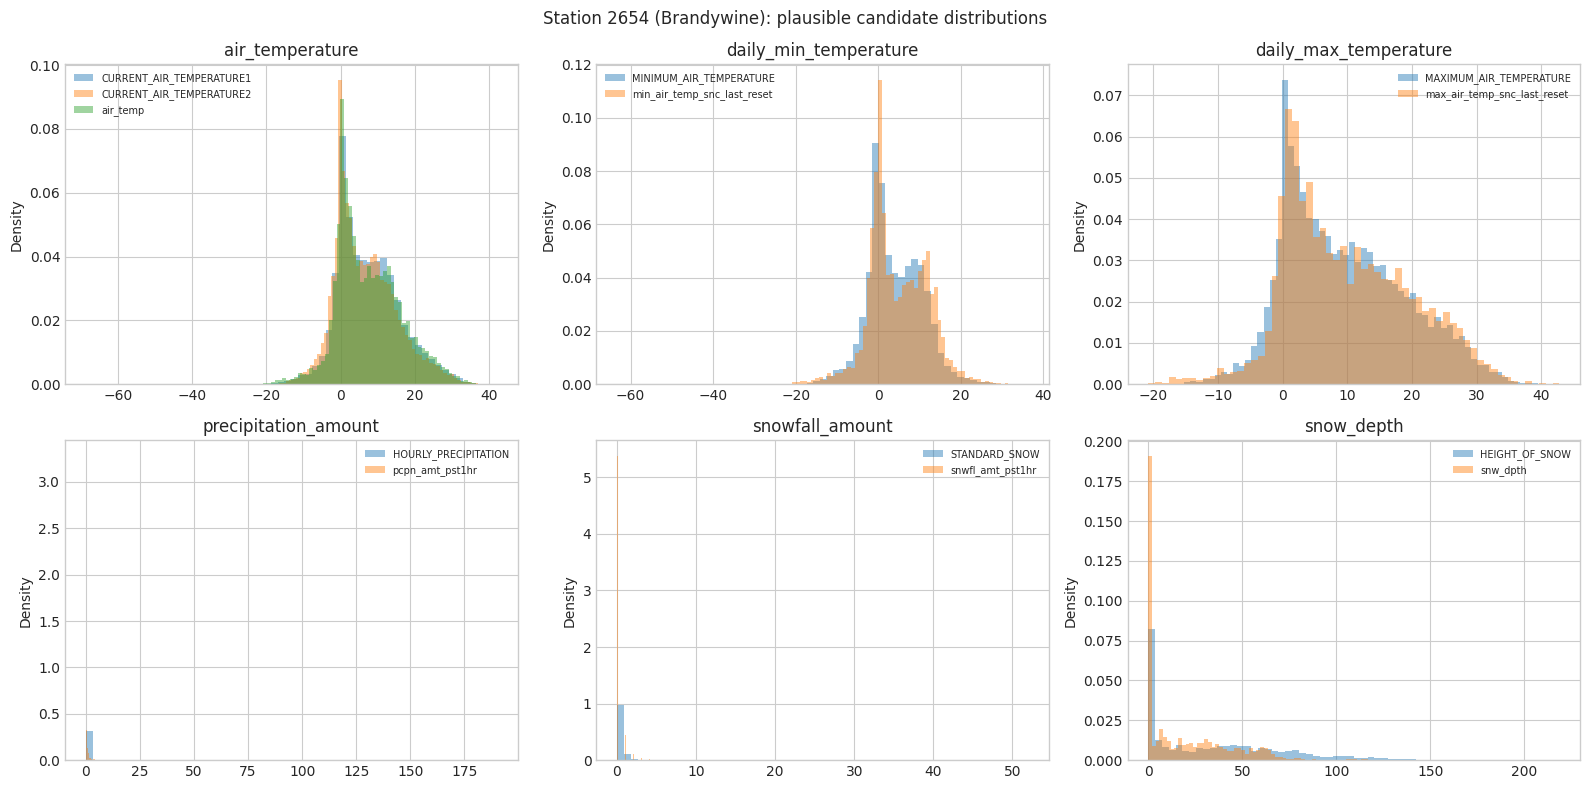

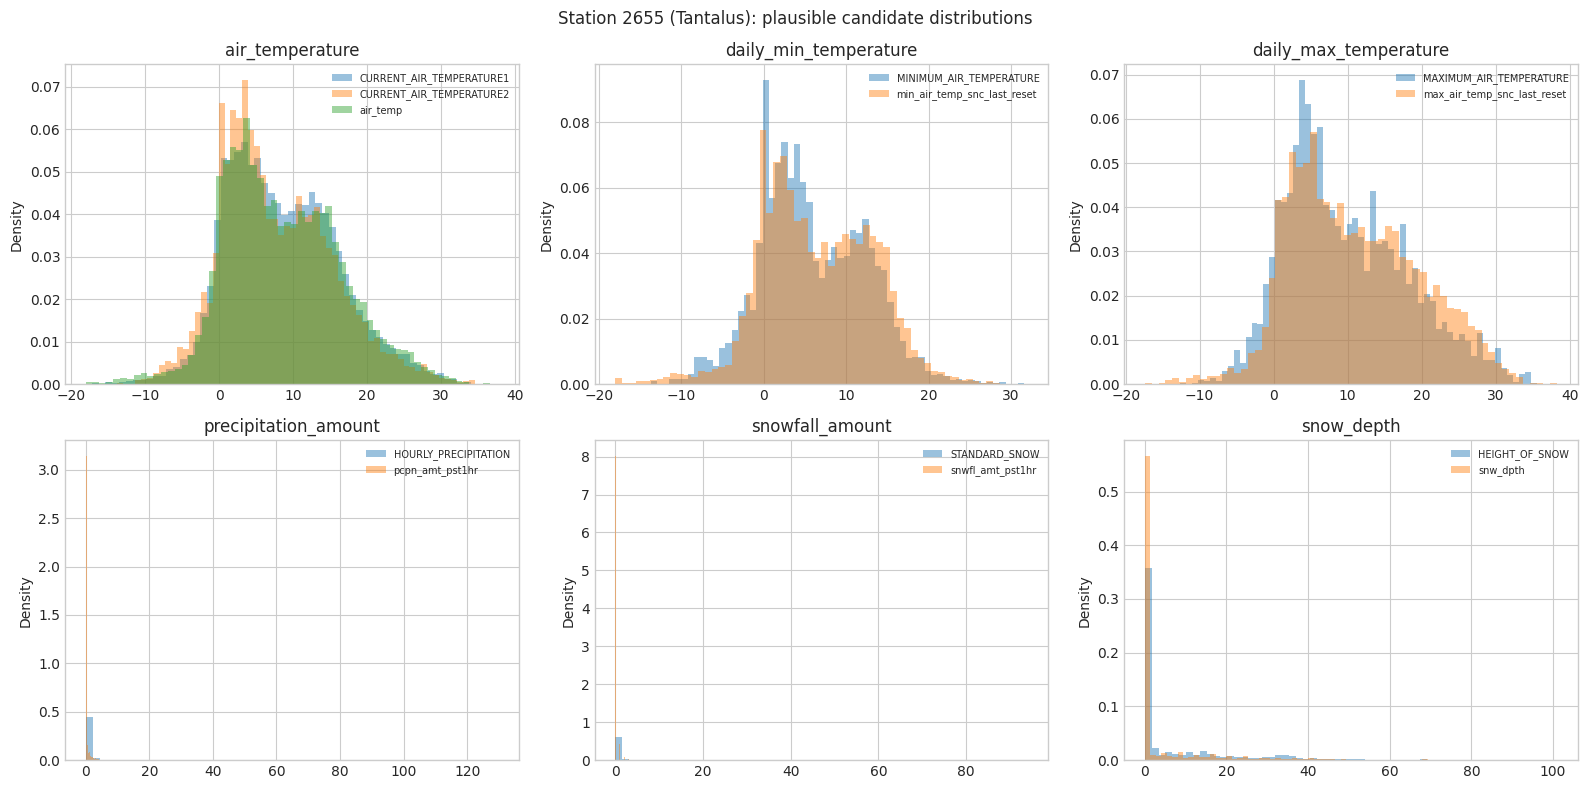

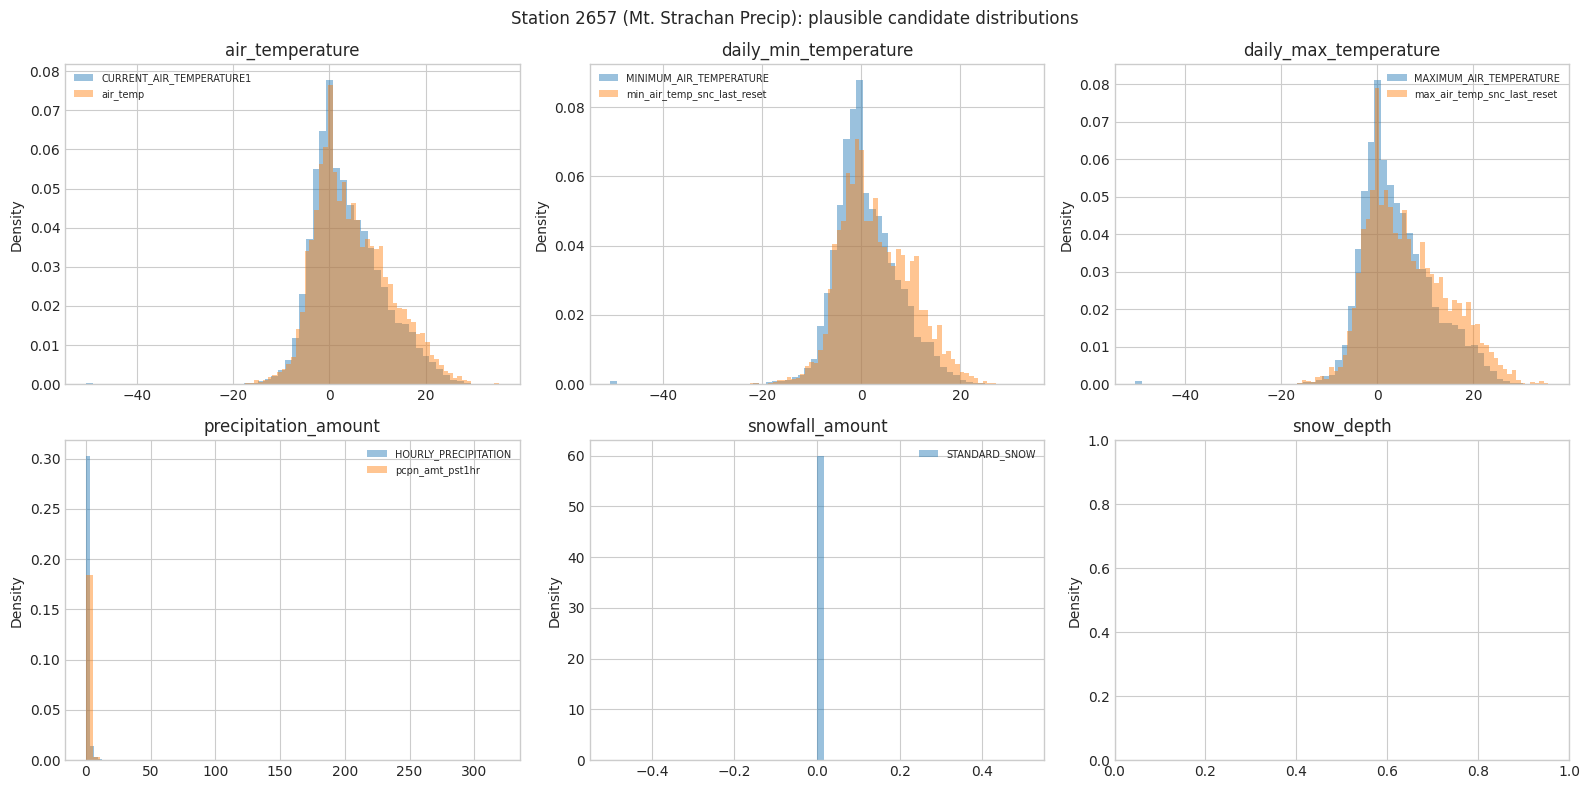

In [12]:
for station_id in sorted(diagnostic_data.station_id.unique()):
    station_data = diagnostic_data[diagnostic_data.station_id == station_id]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, canonical in zip(axes.flat, CANONICAL_VARIABLES):
        subset = station_data[(station_data.canonical_variable == canonical) &
                              ~station_data.is_implausible]
        for source, group in subset.groupby('net_var_name'):
            values = group.datum.dropna()
            if len(values) > 30_000:
                values = values.sample(30_000, random_state=42)
            if len(values):
                ax.hist(values, bins=60, alpha=.45, density=True, label=source)
        ax.set_title(canonical)
        ax.set_ylabel('Density')
        if ax.has_data():
            ax.legend(fontsize=7)
    name = station_data.station_name.iloc[0]
    fig.suptitle(
        f'Station {station_id} ({name}): plausible candidate distributions')
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR/f'station_{station_id}_candidate_distributions.png', dpi=150)
    plt.show()

## 6. Legacy-versus-modern overlap

Agreement at exact timestamps tests whether modern variables are normalized continuations of legacy sources. Running extrema are not expected to equal every legacy extrema reading: reset behavior must be established separately.

In [13]:
SOURCE_PAIRS = {
    'air_temperature': (721, 434), 'daily_min_temperature': (722, 435),
    'daily_max_temperature': (720, 433), 'precipitation_amount': (726, 442),
    'snowfall_amount': (728, 451), 'snow_depth': (727, 450),
}
records = []
for station_id in sorted(stations.station_id.unique()):
    for canonical, (modern_id, legacy_id) in SOURCE_PAIRS.items():
        paired, stats = overlap_comparison(
            observations, int(station_id), modern_id, legacy_id)
        records.append({'station_id': station_id, 'canonical_variable': canonical,
                        'modern_vars_id': modern_id, 'legacy_vars_id': legacy_id, **stats})
overlap_summary = pd.DataFrame(records)
overlap_summary.to_csv(
    OUTPUT_DIR/'legacy_modern_overlap_summary.csv', index=False)
display(overlap_summary)

,station_id,canonical_variable,modern_vars_id,legacy_vars_id,overlap_count,mean_difference,median_absolute_difference,correlation
0,2654,air_temperature,721,434,27120,0.001888,0.0240,0.999995
1,2654,daily_min_temperature,722,435,0,NaN,NaN,NaN
2,2654,daily_max_temperature,720,433,0,NaN,NaN,NaN
3,2654,precipitation_amount,726,442,27378,0.000004,0.0000,1.000000
4,2654,snowfall_amount,728,451,0,NaN,NaN,NaN
5,2654,snow_depth,727,450,16361,0.016189,0.2300,0.999944
6,2655,air_temperature,721,434,27131,0.002416,0.0250,0.999993
7,2655,daily_min_temperature,722,435,0,NaN,NaN,NaN
8,2655,daily_max_temperature,720,433,0,NaN,NaN,NaN
9,2655,precipitation_amount,726,442,27125,-0.000004,0.0000,1.000000


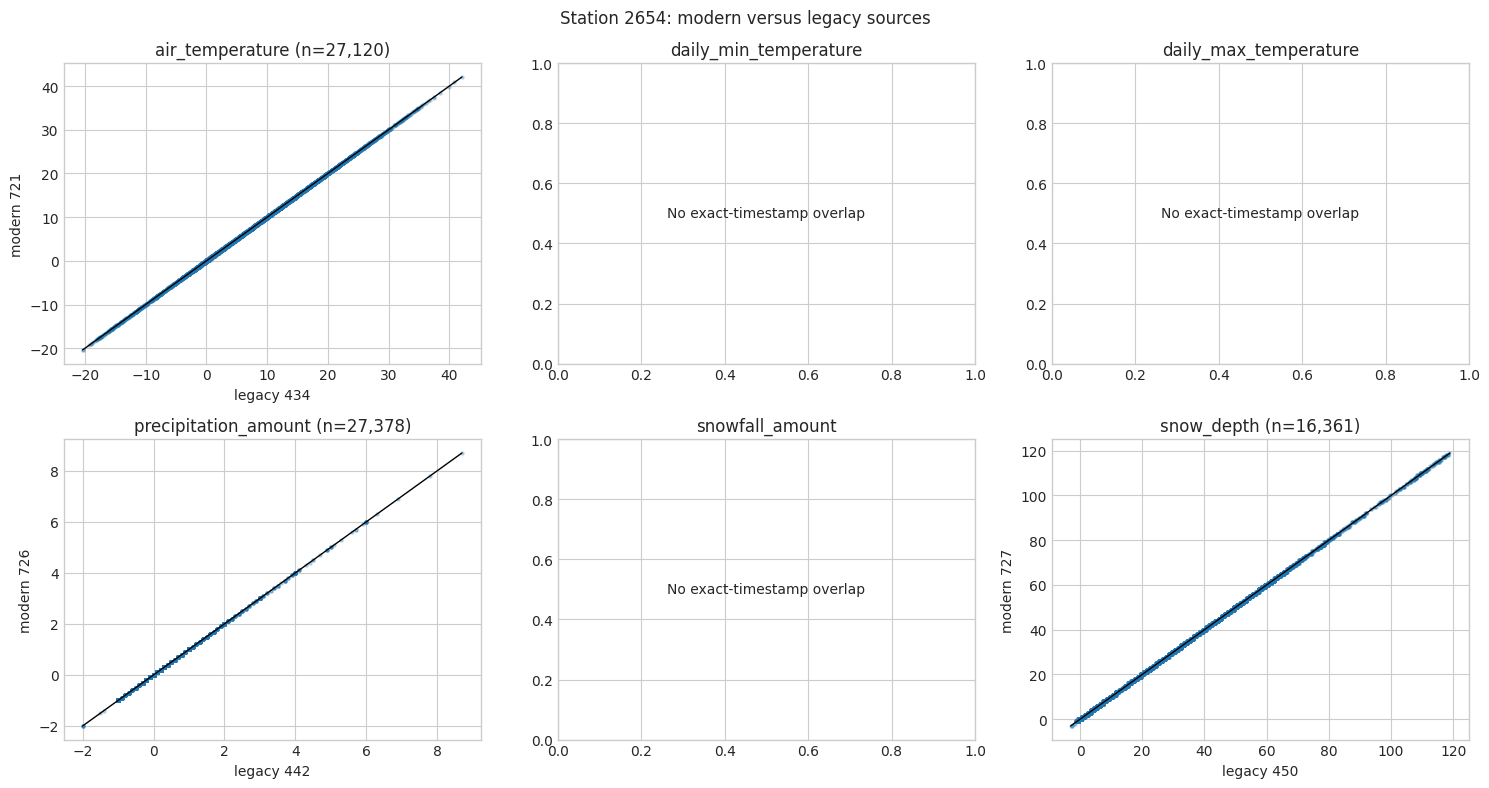

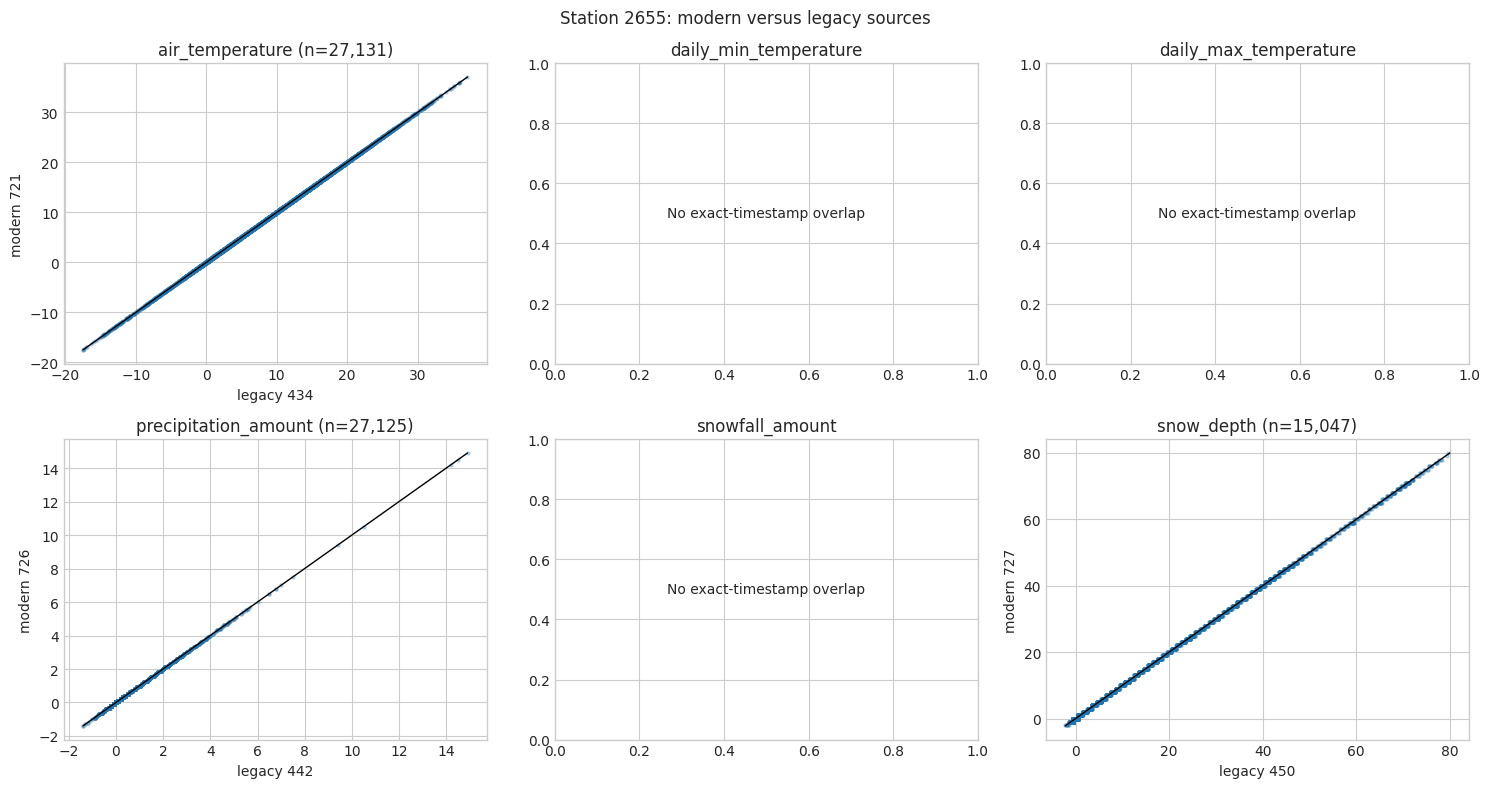

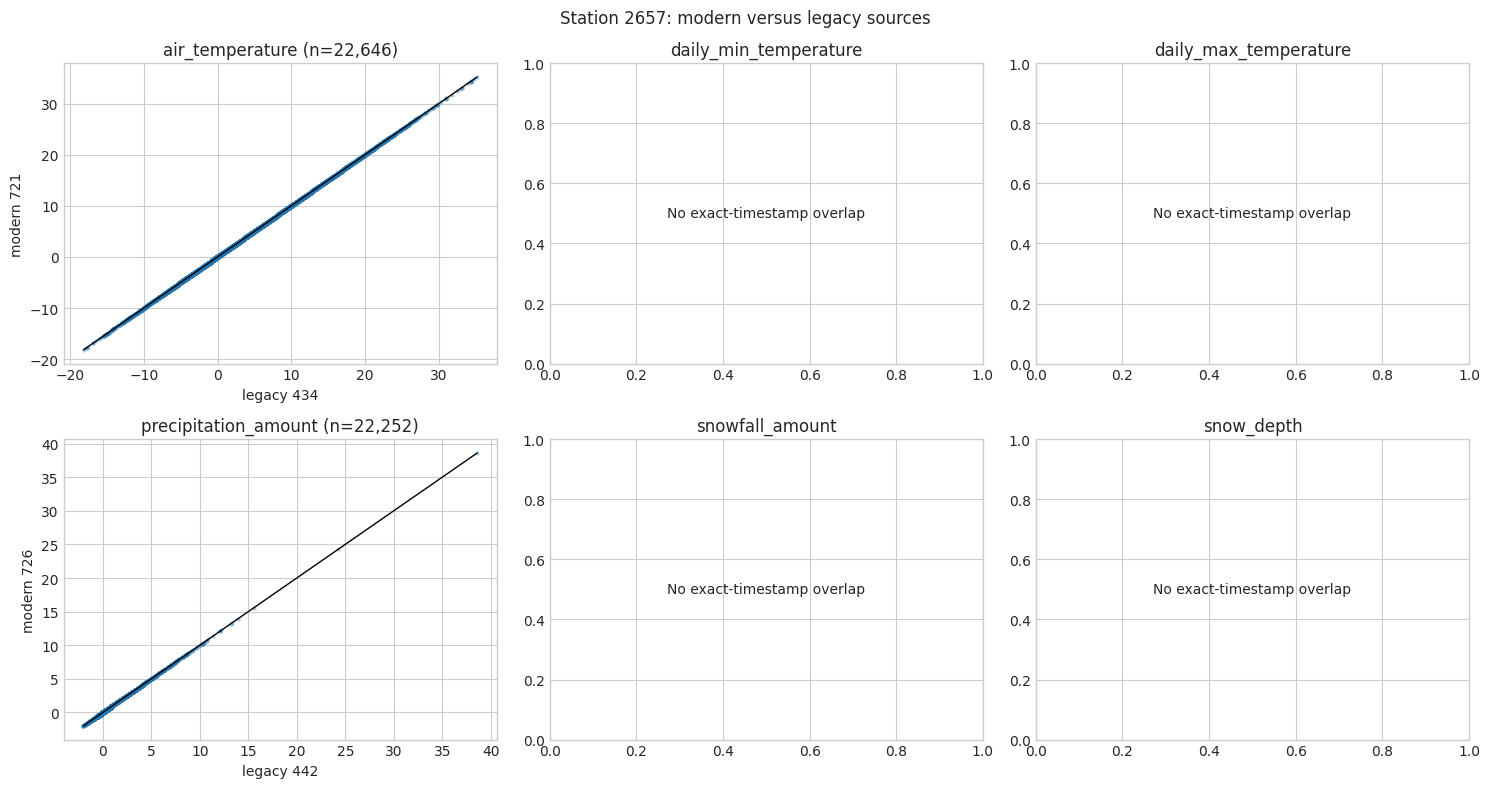

KeyboardInterrupt: 

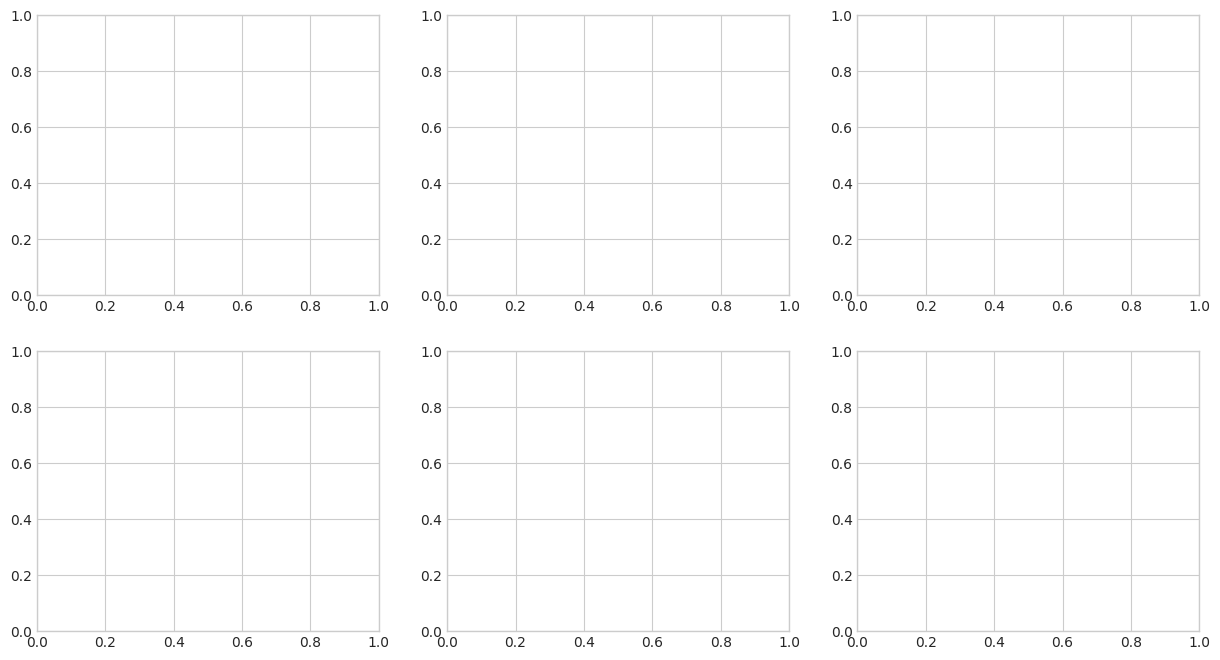

In [ ]:
for station_id in sorted(stations.station_id.unique()):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (canonical, (modern_id, legacy_id)) in zip(axes.flat, SOURCE_PAIRS.items()):
        paired, stats = overlap_comparison(
            observations, int(station_id), modern_id, legacy_id)
        if len(paired):
            sample = paired.sample(min(len(paired), 10_000), random_state=42)
            ax.scatter(sample[legacy_id], sample[modern_id], s=5, alpha=.25)
            low = np.nanmin(sample[[legacy_id, modern_id]].to_numpy())
            high = np.nanmax(sample[[legacy_id, modern_id]].to_numpy())
            ax.plot([low, high], [low, high], color='black', linewidth=1)
            ax.set_title(f'{canonical} (n={len(paired):,})')
            ax.set_xlabel(f'legacy {legacy_id}')
            ax.set_ylabel(f'modern {modern_id}')
        else:
            ax.text(.5, .5, 'No exact-timestamp overlap',
                    ha='center', va='center')
            ax.set_title(canonical)
    fig.suptitle(f'Station {station_id}: modern versus legacy sources')
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR/f'station_{station_id}_source_overlap.png', dpi=150)
    plt.show()

## 7. Export mapping proposal

The proposal retains all available candidates in priority order. It does not silently choose between overlapping sources, and `candidate` is not equivalent to `approved`.

In [ ]:
columns = ['station_id', 'station_name', 'history_id', 'canonical_variable',
           'vars_id', 'net_var_name', 'unit', 'source_type', 'daily_aggregation',
           'priority', 'source_family', 'mapping_status', 'first_observation',
           'last_observation', 'row_count', 'observed_min', 'observed_max']
mapping_proposal = candidate_profile[columns].sort_values(
    ['station_id', 'canonical_variable', 'priority', 'first_observation'])
mapping_proposal.to_csv(OUTPUT_DIR/'station_mapping_proposal.csv', index=False)
display(mapping_proposal)

,station_id,station_name,history_id,canonical_variable,vars_id,net_var_name,unit,source_type,daily_aggregation,priority,source_family,mapping_status,first_observation,last_observation,row_count,observed_min,observed_max
8,2654,Brandywine,3397,air_temperature,721,air_temp,celsius,point,mean,1,modern,candidate,2020-01-08 11:00:00,2026-07-17 09:00:00,45043,-113.000,42.10
1,2654,Brandywine,3397,air_temperature,434,CURRENT_AIR_TEMPERATURE1,celsius,point,mean,2,legacy,candidate,2001-01-22 13:00:00,2023-03-18 09:00:00,187675,-73.320,42.06
3,2654,Brandywine,3397,air_temperature,436,CURRENT_AIR_TEMPERATURE2,celsius,point,mean,3,legacy_fallback,candidate,2001-01-22 13:00:00,2011-04-06 11:00:00,85548,-127.500,40.20
7,2654,Brandywine,3397,daily_max_temperature,720,max_air_temp_snc_last_reset,celsius,running_maximum,last,1,modern,candidate,2020-01-08 11:00:00,2026-07-17 09:00:00,45043,-20.800,42.80
0,2654,Brandywine,3397,daily_max_temperature,433,MAXIMUM_AIR_TEMPERATURE,celsius,interval_maximum,max,2,legacy,candidate,2001-01-22 13:00:00,2011-04-06 11:00:00,88246,-17.390,40.46
10,2654,Brandywine,3397,daily_max_temperature,721,air_temp,celsius,point_fallback,max,3,derived_fallback,candidate,2020-01-08 11:00:00,2026-07-17 09:00:00,45043,-113.000,42.10
11,2654,Brandywine,3397,daily_min_temperature,722,min_air_temp_snc_last_reset,celsius,running_minimum,last,1,modern,candidate,2020-01-08 11:00:00,2026-07-17 09:00:00,45043,-3497.000,36.30
2,2654,Brandywine,3397,daily_min_temperature,435,MINIMUM_AIR_TEMPERATURE,celsius,interval_minimum,min,2,legacy,candidate,2001-01-22 13:00:00,2011-04-06 11:00:00,88225,-117.200,33.94
9,2654,Brandywine,3397,daily_min_temperature,721,air_temp,celsius,point_fallback,min,3,derived_fallback,candidate,2020-01-08 11:00:00,2026-07-17 09:00:00,45043,-113.000,42.10
12,2654,Brandywine,3397,precipitation_amount,726,pcpn_amt_pst1hr,mm,one_hour_amount,sum,1,modern,candidate,2020-01-08 11:00:00,2026-07-17 09:00:00,45033,-2.000,13.10


## 8. Interpretation and next decisions

1. All three stations expose candidates for all six canonical variables, but availability is period-specific and some sources may contain no usable values.
2. Legacy and modern namespaces coexist. Overlapping years must establish whether they are duplicates, corrected replacements, or separate sensors.
3. Raw sentinels and impossible values exist, including extreme negative temperature, snow, and precipitation. Confirmed invalid observations must become `NaN` before daily aggregation.
4. Dedicated Tmin/Tmax sources do not cover every period. Point temperature may provide fallback daily extrema only when daily completeness passes, with provenance marked as derived.
5. `pcpn_amt_pst1hr` has clear one-hour semantics. `HOURLY_PRECIPITATION` has conflicting name/cell-method metadata and must be checked for repetition or accumulation before summing.
6. The reset time for `*_snc_last_reset` is unresolved, so `last` cannot yet be approved as its daily operation.
7. Station timezone metadata is empty. UTC versus local observation-day handling must be decided before authoritative daily outputs.
8. A source containing only sentinels should be classified `NO_VALID_DATA`, not `AVAILABLE` or `POOR QUALITY`.

Next: review the generated mapping evidence, approve source/date-range rules, define sentinel and observation-day policies, and then implement pre-aggregation cleaning plus flexible daily QC.